# SFINCS Scenario Stats

In [ ]:
import sys
from pathlib import Path

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

# model, scenario, storage, and catalog paths.
from sfincs_runs.notebook import load_runtime
# event selection, SFINCS staging, and handoff readiness.
from sfincs_runs.scenarios import scenario_stats as stats
# flood, forcing, and post-run plots.
from sfincs_runs import diagnostics as sfincs_diagnostics

runtime = load_runtime(location_root, wave=True, create_base_model_dir=False)
config = runtime.config
paths = runtime.paths
pd.set_option("display.max_columns", 80)


## Rerun Control


In [ ]:
rerun = False


## Step 0: Load Stats Inputs

Stats are not raw SFINCS outputs alone. They need three folder families:

- `scenarios_root`: prepared SFINCS event folders with `sfincs.inp`, `sfincs.bzs`, and manifests.
- `storage_root`: persisted solver outputs, especially `sfincs_map.nc`.
- `design_outputs_root`: `design_events` outputs that explain the sampled peak, template, return period, and SLR scenario.

These paths come from `sfincs_runs/project.yaml` through `build_paths`.

In [2]:
settings = pd.Series(
    {
        "scenarios_root": str(paths["scenarios_root"]),
        "storage_root": str(paths["storage_root"]),
        "stats_root": str(paths["stats_root"]),
        "design_outputs_root": str(paths["design_outputs_root"]),
        "land_threshold_m": 0.0,
        "huthresh_m": 0.01,
        "impact_threshold_m": 0.10,
    },
    name="value",
)
settings


scenarios_root /home/grahamhults/projects/Flood-RM/locations/...
storage_root /home/grahamhults/projects/Flood-RM/locations/...
stats_root /home/grahamhults/projects/Flood-RM/locations/...
design_outputs_root /home/grahamhults/projects/Flood-RM/locations/...
land_threshold_m 0.0
huthresh_m 0.01
impact_threshold_m 0.1
Name: value, dtype: object

## Step 1

- Which SLR scenario generated this run?
- What return period was sampled?
- Which historical hydrograph template shaped the event?
- Does the SFINCS boundary file match the expected design-event peak?

In [3]:
scenario_summary, scenario_rows = stats.load_scenario_build(paths["scenarios_root"])
design_rows, design_attrs = stats.load_design_events(scenario_summary)

display(pd.Series(scenario_summary, name="scenario_build"))
display(pd.Series(design_attrs, name="design_event_attrs"))

design_frame = pd.DataFrame.from_dict(design_rows, orient="index")
cols = [c for c in ["sample_rp_years", "peak_m", "absolute_peak_m", "template_id", "template_peak_time", "tail_morph_factor"] if c in design_frame]
design_frame[cols].head()


base_model_root /home/grahamhults/projects/Flood-RM/locations/...
design_outputs_root /home/grahamhults/projects/Flood-RM/locations/...
design_scenario base
elapsed_seconds 15.40838
event_count 2
forcing_variable auto
include_precip True
include_waves True
resume False
skipped_existing_count 0
static_file_strategy hardlink_then_copy
surge_dataset /home/grahamhults/projects/Flood-RM/locations/...
target_scenarios_dir /home/grahamhults/projects/Flood-RM/locations/...
written_count 2
zsini_mode boundary_t0
Name: scenario_build, dtype: object

scenario_name base
slr_offset_m 0.0
Name: design_event_attrs, dtype: object

,sample_rp_years,peak_m,absolute_peak_m,template_id,template_peak_time,tail_morph_factor
evt_0001,11.537434,2.645020,NaN,NaN,NaN,NaN
evt_0002,164.926752,3.110907,NaN,NaN,NaN,NaN
evt_0003,5.165293,2.504262,NaN,NaN,NaN,NaN
evt_0004,16.811733,2.710961,NaN,NaN,NaN,NaN
evt_0005,103.716004,3.029664,NaN,NaN,NaN,NaN


## Step 2: Pick Completed Events

A scenario folder is the preferred prepared input. A completed run also has `sfincs_map.nc` in the storage folder.

If `data/sfincs/scenarios` only contains a debug or partial staging set, but `data/sfincs/run_outputs` contains self-contained completed run folders, the next cell falls back to those run-output folders so the evaluation catalogue does not silently shrink.

In [4]:
# Scenario folders are the normal evaluation unit. Run-output folders are a safe fallback
# when they carry the copied sfincs.inp, sfincs.bzs, forcing manifest, and map output.
event_inventory = stats.completed_event_inventory(paths["scenarios_root"], paths["storage_root"])
all_events = event_inventory["all_events"]
completed_events = event_inventory["completed_events"]

LIMIT = 12  # set to None for all completed events in the preview table
selected_events = completed_events[:LIMIT] if LIMIT is not None else completed_events

pd.Series(
    {
        "scenario_folder_count": len(event_inventory["scenario_events"]),
        "storage_run_output_count": len(event_inventory["storage_events"]),
        "scenario_completed_count": len(event_inventory["scenario_completed"]),
        "storage_completed_count": len(event_inventory["storage_completed"]),
        "event_source_root": str(event_inventory["event_source_root"]),
        "using_storage_outputs": bool(event_inventory["use_storage_outputs"]),
        "prepared_event_count": len(all_events),
        "completed_event_count": len(completed_events),
        "selected_event_count": len(selected_events),
        "first_selected_event": selected_events[0].name if selected_events else None,
    }
)


scenario_folder_count 2
storage_run_output_count 500
scenario_completed_count 2
storage_completed_count 500
event_source_root /home/grahamhults/projects/Flood-RM/locations/...
using_storage_outputs True
prepared_event_count 500
completed_event_count 500
selected_event_count 12
first_selected_event design_0001
dtype: object

## Step 2b: Health Check All Runs

Before trusting any aggregate, confirm each event finished cleanly. This cell walks every event in `completed_events` and flags anomalies on three axes:

- `returncode` from `run_metadata.json` (should be 0).
- `sfincs_map.nc` file size (a normal run is tens of MB; near zero means the solver wrote no map output).
- finite-value fraction of the final-timestep `zs` slice (near zero means the solver wrote NaNs across the active grid).

Also surfaces per-event wall-clock duration so outliers — events much slower than the rest — are visible before any downstream analysis. The slow step is opening 500 NetCDFs once (~1 min on a warm cache).

In [5]:
import json
import shutil

health_rows = []
for d in completed_events:
    meta_path = paths["storage_root"] / d.name / "run_metadata.json"
    map_path = paths["storage_root"] / d.name / "sfincs_map.nc"
    rec = {"event_id": d.name, "open_error": ""}

    if meta_path.exists():
        meta = json.loads(meta_path.read_text())
        rec["returncode"] = int(meta.get("returncode", -1))
        rec["duration_min"] = float(meta.get("duration_sec", float("nan"))) / 60.0
    else:
        rec["returncode"] = None
        rec["duration_min"] = float("nan")

    rec["map_mb"] = map_path.stat().st_size / (1024 * 1024) if map_path.exists() else 0.0

    try:
        with xr.open_dataset(map_path, decode_times=False) as ds:
            zs_last = ds["zs"].isel(time=-1).values
            rec["zs_finite_frac"] = float(np.isfinite(zs_last).mean())
            rec["zs_max_last_m"] = float(np.nanmax(zs_last)) if np.any(np.isfinite(zs_last)) else float("nan")
            rec["n_timesteps"] = int(ds.sizes.get("time", 0))
    except Exception as exc:
        rec["zs_finite_frac"] = float("nan")
        rec["zs_max_last_m"] = float("nan")
        rec["n_timesteps"] = 0
        rec["open_error"] = str(exc)[:120]

    health_rows.append(rec)

health = pd.DataFrame(health_rows)

flags = {
    "bad returncode":        health["returncode"].fillna(-1) != 0,
    "tiny map (<1 MB)":      health["map_mb"] < 1.0,
    "open failed":           health["open_error"] != "",
    "empty zs (<5% finite)": health["zs_finite_frac"] < 0.05,
    "missing timesteps":     health["n_timesteps"] < 2,
}

print(f"events checked: {len(health)}\n")
for label, mask in flags.items():
    print(f"  {label:24s} {int(mask.sum())}")

print("\nduration (min):")
display(health["duration_min"].describe().to_frame().T)

flagged_mask = pd.Series(False, index=health.index)
for mask in flags.values():
    flagged_mask = flagged_mask | mask

if flagged_mask.any():
    print(f"\n{int(flagged_mask.sum())} anomalous events:")
    display(health.loc[flagged_mask].sort_values("event_id"))
else:
    print("\nAll events look clean.")


events checked: 500

 bad returncode 0
 tiny map (<1 MB) 0
 open failed 0
 empty zs (<5% finite) 0
 missing timesteps 0

duration (min):


,count,mean,std,min,25%,50%,75%,max
duration_min,500.0,25.469963,1.234788,20.616868,24.541157,25.473149,26.411592,27.861746



All events look clean.


## Step 3: Inspect One Event End to End

For one event, compare the design-event forcing metadata with SFINCS results.

Important metric logic:
- `zs - zb` gives water depth.
- land cells are active cells with bed elevation above `land_threshold_m`.
- baseline wet land at `t0` is not counted as new impact.
- incremental flood depth measures added land depth above the `t0` baseline.
- impact extent uses the configured `impact_threshold_m`.

In [6]:
if not selected_events:
    raise RuntimeError("No completed SFINCS events found. Run scenarios first.")

event_dir = selected_events[0]
row = stats.event_stats(
    event_dir,
    paths["storage_root"],
    settings["land_threshold_m"],
    settings["huthresh_m"],
    settings["impact_threshold_m"],
    scenario_summary,
    scenario_rows,
    design_rows,
    design_attrs,
)

focus = [
    "event_id", "design_scenario", "design_slr_offset_m", "sample_rp_years", "template_id",
    "driver_h_magnitude", "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h", "area_incremental_flooded_ge_24h_km2",
]
pd.Series({k: row.get(k) for k in focus}, name=event_dir.name)


event_id design_0001
design_scenario base
design_slr_offset_m 0.0
sample_rp_years 1.358086
template_id None
driver_h_magnitude None
expected_bzs_peak_max_m 1.943496
bzs_peak_max_m 1.943
peak_incremental_land_depth_m 2.837262
peak_incremental_flooded_area_km2 15.1668
longest_incremental_flood_duration_h 144.0
area_incremental_flooded_ge_24h_km2 11.6784
Name: design_0001, dtype: object

## Step 4: Visualize the One-Event Flood Signal

- left: max incremental land depth per cell.
- right: wet land cell count through time.

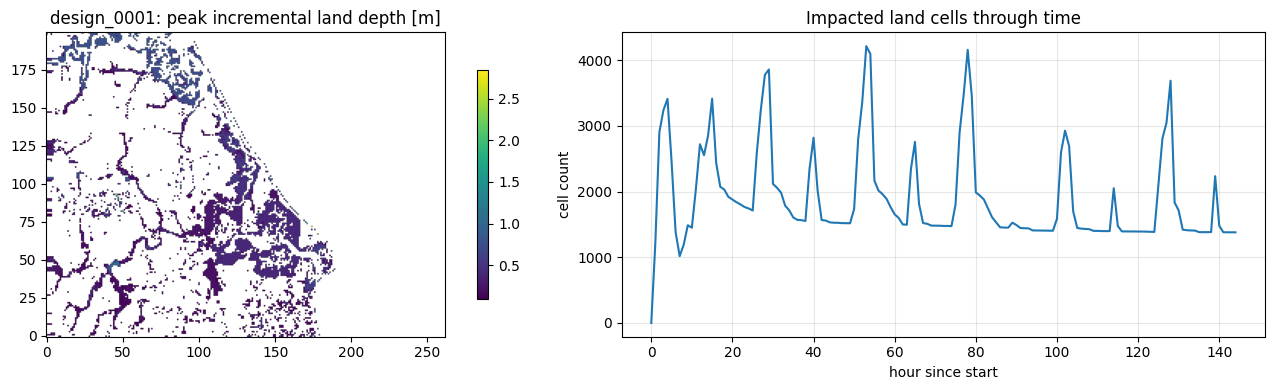

In [7]:
inp = stats.parse_sfincs_inp(event_dir / "sfincs.inp")
with xr.open_dataset(row["map_path"], decode_times=False) as ds:
    zs = np.asarray(ds["zs"].values, np.float32)
    zb = np.asarray(ds["zb"].values, np.float32)
    active = np.asarray(ds["msk"].values, float) > 0
    hours, dt = stats.parse_time(ds, inp)

depth = np.where(active[None,:,:], zs - zb[None,:,:], np.nan)
land = active & np.isfinite(zb) & (zb > settings["land_threshold_m"])
baseline = np.where(land, np.maximum(depth[0], 0.0), np.nan)
incremental = np.where(land[None,:,:], np.maximum(depth - np.nan_to_num(baseline, nan=0.0)[None,:,:], 0.0), np.nan)
impact = np.isfinite(incremental) & (incremental > settings["impact_threshold_m"])

peak_map = np.full(land.shape, np.nan, float)
impacted_cells = np.any(impact, axis=0)
if np.any(impacted_cells):
    peak_map[impacted_cells] = np.nanmax(np.where(impact, incremental, np.nan)[:, impacted_cells], axis=0)
impact_counts = impact.sum(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im = axes[0].imshow(peak_map, origin="lower", cmap="viridis")
axes[0].set_title(f"{event_dir.name}: peak incremental land depth [m]")
fig.colorbar(im, ax=axes[0], shrink=0.75)

axes[1].plot(hours, impact_counts, lw=1.5)
axes[1].set_title("Impacted land cells through time")
axes[1].set_xlabel("hour since start")
axes[1].set_ylabel("cell count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 5: Build the Stats Table

In [8]:
rows = []
for d in selected_events:
    rows.append(
        stats.event_stats(
            d,
            paths["storage_root"],
            settings["land_threshold_m"],
            settings["huthresh_m"],
            settings["impact_threshold_m"],
            scenario_summary,
            scenario_rows,
            design_rows,
            design_attrs,
        )
        )

df = pd.DataFrame(rows).sort_values("event_id").reset_index(drop=True)
display(df[[
    "event_id", "design_scenario", "design_slr_offset_m", "sample_rp_years",
    "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h",
]].head())

df.describe(include="all").T.head(20)


,event_id,design_scenario,design_slr_offset_m,sample_rp_years,expected_bzs_peak_max_m,bzs_peak_max_m,peak_incremental_land_depth_m,peak_incremental_flooded_area_km2,longest_incremental_flood_duration_h
0,design_0001,base,0.0,1.358086,1.943496,1.943,2.837262,15.1668,144.0
1,design_0002,base,0.0,0.136579,1.849395,1.849,3.354710,13.4820,142.0
2,design_0003,base,0.0,0.679544,1.673804,1.674,3.414282,14.3964,143.0
3,design_0004,base,0.0,0.146902,1.491863,1.492,1.503457,8.8344,140.0
4,design_0005,base,0.0,1.159456,1.792010,1.792,3.422685,18.6912,139.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,12,12,design_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scenario_dir,12,12,/home/grahamhults/projects/Flood-RM/locations/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
map_path,12,12,/home/grahamhults/projects/Flood-RM/locations/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
log_path,12,12,/home/grahamhults/projects/Flood-RM/locations/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
design_outputs_root,12,1,/home/grahamhults/projects/Flood-RM/locations/...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
design_scenario,12,1,base,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
design_slr_offset_m,12.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
source_event_index,1.0,NaN,NaN,NaN,2.0,NaN,2.0,2.0,2.0,2.0,2.0
sample_rp_years,12.0,NaN,NaN,NaN,0.612723,0.426647,0.136579,0.217925,0.650839,0.83461,1.358086
probability_weight,12.0,NaN,NaN,NaN,0.02972,0.0,0.02972,0.02972,0.02972,0.02972,0.02972


## Step 6: Check Alignment Between Inputs and Flood Outputs

- boundary peak from `sfincs.bzs` should track the design-event expected boundary peak.
- return period and SLR scenario should be available beside flood metrics.
- flood extent/depth rankings should point back to event IDs for map inspection.

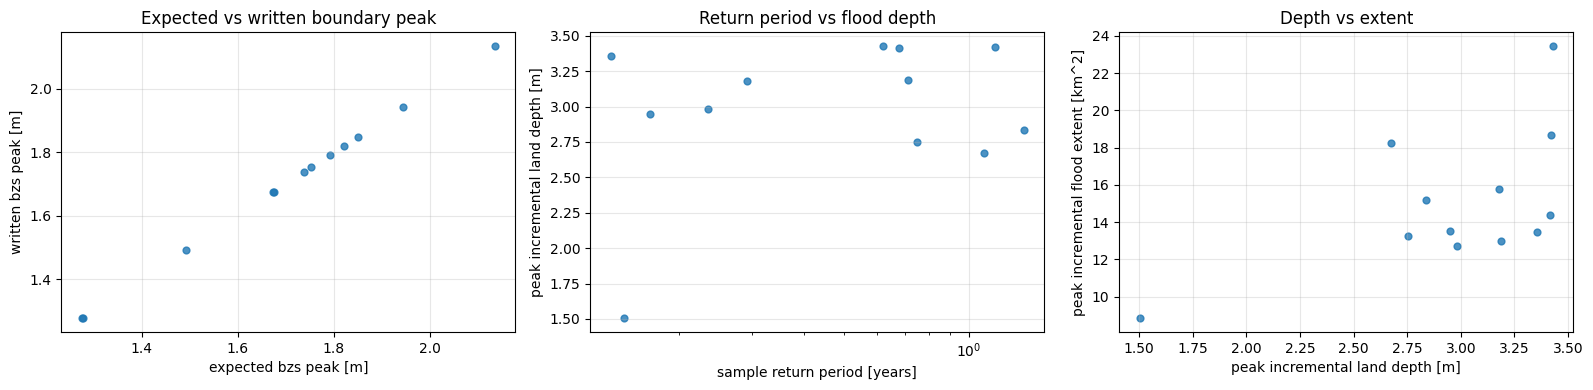

,event_id,design_scenario,sample_rp_years,peak_incremental_land_depth_m,peak_incremental_flooded_area_km2
5,design_0006,base,0.622134,3.427522,23.4504
4,design_0005,base,1.159456,3.422685,18.6912
2,design_0003,base,0.679544,3.414282,14.3964
1,design_0002,base,0.136579,3.354710,13.4820
11,design_0012,base,0.715306,3.187110,12.9960
10,design_0011,base,0.291354,3.179409,15.7896
7,design_0008,base,0.233868,2.979819,12.7476
8,design_0009,base,0.170099,2.949630,13.5360
0,design_0001,base,1.358086,2.837262,15.1668
6,design_0007,base,0.749548,2.752190,13.2840


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df["expected_bzs_peak_max_m"], df["bzs_peak_max_m"], s=24, alpha=0.8)
axes[0].set_title("Expected vs written boundary peak")
axes[0].set_xlabel("expected bzs peak [m]")
axes[0].set_ylabel("written bzs peak [m]")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df["sample_rp_years"], df["peak_incremental_land_depth_m"], s=24, alpha=0.8)
axes[1].set_xscale("log")
axes[1].set_title("Return period vs flood depth")
axes[1].set_xlabel("sample return period [years]")
axes[1].set_ylabel("peak incremental land depth [m]")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(df["peak_incremental_land_depth_m"], df["peak_incremental_flooded_area_km2"], s=24, alpha=0.8)
axes[2].set_title("Depth vs extent")
axes[2].set_xlabel("peak incremental land depth [m]")
axes[2].set_ylabel("peak incremental flood extent [km^2]")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df.sort_values("peak_incremental_land_depth_m", ascending=False)[["event_id", "design_scenario", "sample_rp_years", "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2"]].head(10)


## Step 7: Write Notebook Outputs

In [10]:
outdir = paths["stats_root"] / "notebook"
outdir.mkdir(parents=True, exist_ok=True)

csv_path = outdir / "scenario_stats_notebook.csv"
df.to_csv(csv_path, index=False)

metric_cols = [
    "zsini_m", "baseline_t0_flooded_area_km2", "peak_incremental_land_depth_m",
    "peak_incremental_flooded_area_km2", "anytime_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h", "mean_incremental_flood_duration_h",
    "area_incremental_flooded_ge_24h_km2",
]
summary = {
    "event_count": int(len(df)),
    "design_outputs_root": scenario_summary.get("design_outputs_root"),
    "design_scenarios": sorted(str(x) for x in df["design_scenario"].dropna().unique()),
    "design_slr_offsets_m": sorted(float(x) for x in pd.to_numeric(df["design_slr_offset_m"], errors="coerce").dropna().unique()),
    "metric_summaries": {c: stats.series_summary(df, c) for c in metric_cols},
}

(outdir / "summary_notebook.json").write_text(__import__("json").dumps(summary, indent=2), encoding="utf-8")
pd.Series({"csv": str(csv_path), "summary": str(outdir / "summary_notebook.json")})


csv /home/grahamhults/projects/Flood-RM/locations/...
summary /home/grahamhults/projects/Flood-RM/locations/...
dtype: str

## Step 8: Export Run-Output Catalogue

In [11]:
# Catalogue join: completed run_outputs -> Event Catalog descriptors -> flood outcome metrics.
import json
import numpy as np

ENSURE_RUN_OUTPUT_GRID_FILES = True
catalogue_path = outdir / "flood_event_outcome_catalogue.csv"

catalogue_events = completed_events
run_index = pd.DataFrame(
    {
        "event_id": [d.name for d in catalogue_events],
        "scenario_dir": [str(d) for d in catalogue_events],
        "run_output_dir": [str(paths["storage_root"] / d.name) for d in catalogue_events],
    }
)

def _link_or_copy_file(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        dst.hardlink_to(src)
    except OSError:
        shutil.copy2(src, dst)


def _ensure_run_output_grid_files(event_dirs):
    rows = []
    for event_dir in event_dirs:
        inp = stats.parse_sfincs_inp(event_dir / "sfincs.inp")
        grid_name = inp.get("qtrfile")
        if not grid_name:
            continue
        target = event_dir / str(grid_name)
        if target.exists():
            rows.append({"event_id": event_dir.name, "grid_file": str(target), "status": "present"})
            continue
        manifest_path = event_dir / "forcing_manifest.json"
        manifest = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.exists() else {}
        metadata_path = event_dir / "run_metadata.json"
        metadata = json.loads(metadata_path.read_text(encoding="utf-8")) if metadata_path.exists() else {}
        candidates = []
        for root_key in ["base_model_root", "source_scenario_dir"]:
            root = manifest.get(root_key) or metadata.get(root_key)
            if root:
                candidates.append(Path(root) / str(grid_name))
        candidates.append(paths["scenarios_root"] / event_dir.name / str(grid_name))
        source = next((path for path in candidates if path.exists()), None)
        if source is None:
            rows.append({"event_id": event_dir.name, "grid_file": str(target), "status": "missing_source"})
            continue
        _link_or_copy_file(source, target)
        rows.append({"event_id": event_dir.name, "grid_file": str(target), "source_grid_file": str(source), "status": "materialized"})
    frame = pd.DataFrame(rows)
    if not frame.empty and (frame["status"] == "missing_source").any():
        missing = frame.loc[frame["status"] == "missing_source", "event_id"].head(10).tolist()
        raise FileNotFoundError(f"Could not materialize qtrfile for run outputs: {missing}")
    return frame


if ENSURE_RUN_OUTPUT_GRID_FILES:
    grid_file_status = _ensure_run_output_grid_files(catalogue_events)
    if not grid_file_status.empty:
        display(grid_file_status.groupby("status").size().rename("run_output_grid_files").reset_index())

catalogue_stats_path = paths["stats_root"] / "scenario_stats.csv"
if rerun:
    catalogue_outcomes = pd.DataFrame()
    missing_outcome_ids = run_index["event_id"].tolist()
elif catalogue_stats_path.exists():
    catalogue_outcomes = pd.read_csv(catalogue_stats_path)
    missing_outcome_ids = sorted(set(run_index["event_id"]) - set(catalogue_outcomes["event_id"].astype(str)))
elif catalogue_path.exists():
    catalogue_outcomes = pd.read_csv(catalogue_path)
    missing_outcome_ids = sorted(set(run_index["event_id"]) - set(catalogue_outcomes["event_id"].astype(str)))
else:
    catalogue_outcomes = pd.DataFrame()
    missing_outcome_ids = run_index["event_id"].tolist()

if missing_outcome_ids:
    mode = "Rebuilding" if rerun else "Building missing"
    print(f"{mode} catalogue outcome metrics for {len(missing_outcome_ids)} completed events...")
    missing_outcome_set = set(missing_outcome_ids)
    fresh_rows = []
    for i, d in enumerate([d for d in catalogue_events if d.name in missing_outcome_set], start=1):
        fresh_rows.append(
            stats.event_stats(
                d,
                paths["storage_root"],
                settings["land_threshold_m"],
                settings["huthresh_m"],
                settings["impact_threshold_m"],
                scenario_summary,
                scenario_rows,
                design_rows,
                design_attrs,
            )
            )
        if i % 50 == 0 or i == len(missing_outcome_ids):
            print(f"  {i}/{len(missing_outcome_ids)} outcome rows")
    fresh_outcomes = pd.DataFrame(fresh_rows)
    catalogue_outcomes = pd.concat([catalogue_outcomes, fresh_outcomes], ignore_index=True)

catalogue_outcomes = catalogue_outcomes[catalogue_outcomes["event_id"].astype(str).isin(set(run_index["event_id"]))]

# Event Catalog rows are the physical forcing contract for these SFINCS runs.
event_catalog_path = paths["design_outputs_root"] / "catalog" / "event_catalog.csv"
event_catalog = pd.read_csv(event_catalog_path).rename(
    columns={
        "event_reference_time": "catalog_event_reference_time",
        "event_drivers": "driver_combo",
    }
)
event_catalog["event_catalog_csv"] = str(event_catalog_path)

# Driver magnitudes follow the Marshfield Event Catalog schema: coastal peak [m] plus AORC 72h mean rainfall [mm].
rainfall_table_cache = {}
rainfall_metrics = []
for _, event_row in event_catalog.iterrows():
    rainfall_file = event_row.get("rainfall_member_file")
    rainfall_time = pd.to_datetime(event_row.get("rainfall_member_time"), errors="coerce")
    rainfall_metric = np.nan
    if pd.notna(rainfall_time) and isinstance(rainfall_file, str) and rainfall_file.strip():
        rainfall_path = Path(rainfall_file)
        if rainfall_path.exists():
            if rainfall_path not in rainfall_table_cache:
                rainfall_table_cache[rainfall_path] = pd.read_csv(rainfall_path)
            rainfall_table = rainfall_table_cache[rainfall_path]
            matched = rainfall_table[pd.to_datetime(rainfall_table["storm_date"], errors="coerce") == rainfall_time]
            if not matched.empty and "mean" in matched:
                rainfall_metric = float(matched.iloc[0]["mean"])
    rainfall_metrics.append(rainfall_metric)
event_catalog["rainfall_metric_mm"] = rainfall_metrics
event_catalog["driver_h_magnitude"] = pd.to_numeric(event_catalog.get("coastal_absolute_peak_m"), errors="coerce")
event_catalog["driver_p_magnitude"] = pd.to_numeric(event_catalog["rainfall_metric_mm"], errors="coerce")

# The Event Catalog carries browsing labels for every staged run; the stress/training table fills older synthetic rows.
stress_catalog_path = paths["design_outputs_root"] / "catalog" / "resilience_stress_training_catalog.csv"
stress_cols = [
    "event_id", "event_origin", "catalog_role", "storm_type", "event_set",
    "selection_role", "selection_reason", "benchmark_return_period_years",
    "compound_pairing_policy", "compound_pairing_role", "scenario_timing_edge_case",
]
stress_cols = [c for c in stress_cols if c in pd.read_csv(stress_catalog_path, nrows=0).columns]
stress_catalog = pd.read_csv(stress_catalog_path, usecols=stress_cols)
stress_catalog = stress_catalog.rename(columns={c: f"{c}_stress" for c in stress_catalog.columns if c != "event_id"})
stress_catalog["classification_catalog_csv"] = str(stress_catalog_path)

manifest_rows = []
for d in catalogue_events:
    manifest_path = paths["storage_root"] / d.name / "forcing_manifest.json"
    manifest = json.loads(manifest_path.read_text())
    manifest_rows.append(
    {
            "event_id": d.name,
            "run_event_reference_time": manifest.get("event_reference_time"),
            "run_start": manifest.get("run_start"),
            "run_stop": manifest.get("run_stop"),
            "run_duration_hours": manifest.get("run_duration_hours"),
            "model_t_start": manifest.get("t_start"),
            "model_t_stop": manifest.get("t_stop"),
            "timing_policy": manifest.get("timing_policy"),
            "forcing_variable": manifest.get("forcing_variable"),
            "expected_has_precip": manifest.get("expected_has_precip"),
            "expected_has_waves": manifest.get("expected_has_waves"),
            "initial_soil_moisture_fraction": manifest.get("initial_soil_moisture_fraction"),
            "run_soil_moisture_member_file": manifest.get("soil_moisture_member_file"),
            "run_soil_moisture_member_id": manifest.get("soil_moisture_member_id"),
            "run_soil_moisture_member_time": manifest.get("soil_moisture_member_time"),
            "soil_moisture_included_in_run": (
                manifest.get("initial_soil_moisture_fraction") is not None
                or any(str(manifest.get(k) or "").strip() for k in ["soil_moisture_member_file", "soil_moisture_member_id", "soil_moisture_member_time"])
            ),
            "driver_windows": json.dumps(manifest.get("driver_windows", [])),
            "prepared_precip": manifest.get("prepared_precip"),
            "rainfall_source_nc": manifest.get("rainfall_source_nc"),
            "surge_dataset": manifest.get("surge_dataset"),
            "base_model_root": manifest.get("base_model_root"),
    }
            )
manifest_frame = pd.DataFrame(manifest_rows)

outcome_cols = [
    "event_id", "map_path", "design_scenario", "design_slr_offset_m",
    "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "anytime_incremental_flooded_area_km2", "peak_newly_flooded_area_km2",
    "anytime_newly_flooded_area_km2", "longest_incremental_flood_duration_h",
    "mean_incremental_flood_duration_h", "area_incremental_flooded_ge_24h_km2",
    "cumulative_incremental_flooded_area_km2h", "available_time_steps",
    "last_output_hour", "active_cells", "land_t0_cells", "cell_area_m2",
]
outcome_cols = [c for c in outcome_cols if c in catalogue_outcomes.columns]

health_cols = [
    "event_id", "returncode", "duration_min", "map_mb", "n_timesteps",
    "zs_finite_frac", "zs_max_last_m", "open_error",
]
health_cols = [c for c in health_cols if c in health.columns]

catalogue = (
 run_index.merge(event_catalog, on="event_id", how="left").merge(stress_catalog, on="event_id", how="left").merge(manifest_frame, on="event_id", how="left").merge(catalogue_outcomes[outcome_cols], on="event_id", how="left").merge(health[health_cols], on="event_id", how="left")
)

label_cols = [
    "event_origin", "catalog_role", "storm_type", "event_set",
    "selection_role", "selection_reason", "benchmark_return_period_years",
    "compound_pairing_policy", "compound_pairing_role", "scenario_timing_edge_case",
]
for col in label_cols:
    stress_col = f"{col}_stress"
    if col not in catalogue and stress_col in catalogue:
        catalogue[col] = catalogue[stress_col]
    elif stress_col in catalogue:
        catalogue[col] = catalogue[col].combine_first(catalogue[stress_col])

soil_cols = ["soil_moisture_source", "soil_moisture_member_id", "soil_moisture_member_time"]
for col in soil_cols:
    if col not in catalogue:
        catalogue[col] = ""
    catalogue[col] = catalogue[col].astype("object")
soil_absent = ~catalogue["soil_moisture_included_in_run"].fillna(False).astype(bool)
catalogue.loc[soil_absent, soil_cols] = "not_staged"

for col in ["event_origin", "storm_type", "severity_band", "driver_combo"]:
    if col not in catalogue:
        catalogue[col] = "unresolved"
    catalogue[col] = catalogue[col].fillna("unresolved").astype(str)

origin_group = catalogue["event_origin"].copy()
origin_group[origin_group.str.contains("historical", case=False, na=False)] = "historical"
origin_group[origin_group.str.contains("synthetic", case=False, na=False)] = "synthetic"
origin_group[origin_group.isin(["", "nan", "unresolved"])] = "unresolved"
catalogue.insert(0, "event_origin_group", origin_group)
catalogue.insert(
    1,
    "catalogue_section",
    catalogue["event_origin_group"] + " / " + catalogue["storm_type"] + " / " + catalogue["severity_band"],
)

severity_rank = {"mild": 0, "common": 1, "significant": 2, "rare": 3, "extreme": 4}
catalogue["_severity_rank"] = catalogue["severity_band"].map(severity_rank).fillna(99)
catalogue["_sample_rp_sort"] = pd.to_numeric(catalogue.get("sample_rp_years"), errors="coerce")
catalogue["_depth_sort"] = pd.to_numeric(catalogue.get("peak_incremental_land_depth_m"), errors="coerce")
catalogue = catalogue.sort_values(
    ["event_origin_group", "event_origin", "storm_type", "_severity_rank", "_sample_rp_sort", "_depth_sort", "event_id"],
    ascending=[True, True, True, True, True, False, True],
).drop(columns=["_severity_rank", "_sample_rp_sort", "_depth_sort"])

front_cols = [
    "event_origin_group", "catalogue_section", "event_origin", "storm_type", "severity_band",
    "event_id", "event_set", "catalog_role", "selection_role", "selection_reason",
    "sample_rp_years", "sampling_scheme", "sampling_region", "sampling_weight", "probability_weight",
    "driver_combo", "forcing_pairing_policy", "infiltration_treatment",
    "catalog_event_reference_time", "run_event_reference_time", "run_start", "run_stop", "run_duration_hours",
    "coastal_source", "coastal_member_id", "coastal_template_peak_time", "coastal_peak_m",
    "coastal_absolute_peak_m", "coastal_analog_id", "coastal_analog_peak_time",
    "coastal_water_level_scale_factor", "snapwave_source", "snapwave_member_id",
    "snapwave_valid_start_time", "snapwave_valid_end_time", "snapwave_pairing_policy",
    "rainfall_source", "rainfall_member_id", "rainfall_member_time", "rainfall_metric_mm", "rainfall_scale_factor",
    "rainfall_pairing_policy", "rainfall_pairing_reference_time", "rainfall_pairing_lag_hours",
    "soil_moisture_included_in_run", "soil_moisture_source", "soil_moisture_member_id", "soil_moisture_member_time",
    "driver_h_magnitude", "driver_p_magnitude", "expected_has_precip", "expected_has_waves",
    "initial_soil_moisture_fraction", "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "anytime_incremental_flooded_area_km2", "peak_newly_flooded_area_km2",
    "anytime_newly_flooded_area_km2", "longest_incremental_flood_duration_h",
    "mean_incremental_flood_duration_h", "area_incremental_flooded_ge_24h_km2",
    "cumulative_incremental_flooded_area_km2h", "returncode", "duration_min", "map_mb", "n_timesteps",
    "available_time_steps", "last_output_hour", "run_output_dir", "scenario_dir", "map_path",
    "prepared_precip", "rainfall_source_nc", "surge_dataset", "base_model_root",
    "event_catalog_csv", "classification_catalog_csv",
]
front_cols = [c for c in front_cols if c in catalogue.columns]
catalogue = catalogue[front_cols + [c for c in catalogue.columns if c not in front_cols]]

catalogue.to_csv(catalogue_path, index=False)

display(catalogue.groupby(["event_origin_group", "storm_type", "severity_band"], dropna=False).size().rename("event_count").reset_index())
pd.Series({
    "catalogue_csv": str(catalogue_path),
    "events": int(len(catalogue)),
    "rerun": bool(rerun),
    "outcome_metrics_built": int(len(missing_outcome_ids)),
})


,status,run_output_grid_files
0,present,500


Rebuilding catalogue outcome metrics for 500 completed events...
 50/500 outcome rows
 100/500 outcome rows
 150/500 outcome rows
 200/500 outcome rows
 250/500 outcome rows
 300/500 outcome rows
 350/500 outcome rows
 400/500 outcome rows
 450/500 outcome rows
 500/500 outcome rows


,event_origin_group,storm_type,severity_band,event_count
0,synthetic,nor_easter,common,109
1,synthetic,nor_easter,extreme,75
2,synthetic,nor_easter,mild,15
3,synthetic,nor_easter,rare,38
4,synthetic,nor_easter,significant,87
5,synthetic,other_non_tropical,common,27
6,synthetic,other_non_tropical,extreme,59
7,synthetic,other_non_tropical,mild,10
8,synthetic,other_non_tropical,rare,19
9,synthetic,other_non_tropical,significant,36


catalogue_csv /home/grahamhults/projects/Flood-RM/locations/...
events 500
reran_outcome_metrics True
outcome_metrics_built 500
dtype: object

## Step 9: Return-Period Flood Diagnostics

Read the exported event-outcome catalogue back as the analysis unit: one completed event per row, carrying the sampled joint return period, driver magnitudes, storm class, and SFINCS flood-response metrics.

catalogue_csv /home/grahamhults/projects/Flood-RM/locations/...
events 500
storm_types nor_easter, other_non_tropical, tc
max_anytime_incremental_area_km2 39.1752
max_peak_incremental_depth_m 4.865133
Name: flood_catalogue_scope, dtype: object

,rp_band,severity_band,event_count,median_rp_years,median_peak_boundary_m,median_rainfall_mm,flood_hit_rate,median_peak_depth_m,p90_peak_depth_m,median_peak_area_km2,p90_anytime_area_km2,p90_longest_duration_h
0,<2 yr,mild,25,0.354,1.710,67.354,1.0,3.182,3.422,14.497,24.311,144.0
1,2-10 yr,common,140,3.370,1.880,121.896,1.0,3.418,3.452,20.178,31.591,144.0
2,10-50 yr,significant,140,19.978,2.019,152.992,1.0,3.423,3.725,22.459,32.777,144.0
3,50-100 yr,rare,60,62.132,2.174,174.204,1.0,3.436,3.893,23.987,34.051,144.0
4,100-500 yr,extreme,135,172.895,2.035,200.393,1.0,3.454,3.949,24.682,35.120,144.0


,storm_type,severity_band,event_count,median_rp_years,median_peak_boundary_m,median_rainfall_mm,median_peak_area_km2,p90_anytime_area_km2,p90_longest_duration_h
0,nor_easter,common,109,3.383,1.916,111.644,19.804,31.333,144.0
1,nor_easter,extreme,75,172.895,2.538,157.230,24.012,34.371,144.0
2,nor_easter,mild,15,0.370,1.792,67.354,15.790,24.070,143.6
3,nor_easter,rare,38,61.168,2.557,149.529,23.686,32.821,144.0
4,nor_easter,significant,87,17.739,2.297,143.402,21.125,31.710,144.0
5,other_non_tropical,common,27,3.285,1.676,186.118,23.785,32.767,144.0
6,other_non_tropical,extreme,59,172.895,1.781,217.902,26.334,35.438,144.0
7,other_non_tropical,mild,10,0.264,1.551,66.947,13.142,23.847,144.0
8,other_non_tropical,rare,19,65.623,1.599,217.902,26.075,35.254,144.0
9,other_non_tropical,significant,36,21.275,1.627,216.242,25.216,34.308,143.0


,event_id,storm_type,severity_band,sample_rp_years,coastal_absolute_peak_m,rainfall_metric_mm,bzs_peak_max_m,peak_incremental_land_depth_m,peak_incremental_flooded_area_km2,anytime_incremental_flooded_area_km2,longest_incremental_flood_duration_h
434,design_0442,other_non_tropical,extreme,118.514,1.914,216.242,1.830,3.913,30.899,39.175,144.0
426,design_0392,other_non_tropical,extreme,104.287,1.445,297.734,1.957,3.915,33.534,38.966,144.0
206,design_0296,nor_easter,significant,17.192,2.487,83.470,2.074,3.520,32.987,37.915,144.0
477,design_0416,other_non_tropical,extreme,475.085,1.408,240.053,1.892,4.152,33.901,37.490,138.0
494,design_0191,tc,significant,38.206,1.927,145.285,2.654,3.500,30.395,37.490,141.0
423,design_0430,other_non_tropical,extreme,103.737,1.511,217.862,1.882,4.865,29.308,37.480,140.0
359,design_0380,nor_easter,extreme,312.198,2.673,183.086,2.550,3.463,30.532,37.282,141.0
174,design_0295,nor_easter,significant,10.765,1.921,192.155,2.007,3.572,31.406,37.030,141.0
331,design_0407,nor_easter,extreme,173.444,1.680,200.393,2.658,3.451,29.779,36.871,141.0
176,design_0170,nor_easter,significant,10.914,1.945,198.904,2.546,3.451,29.477,36.774,140.0


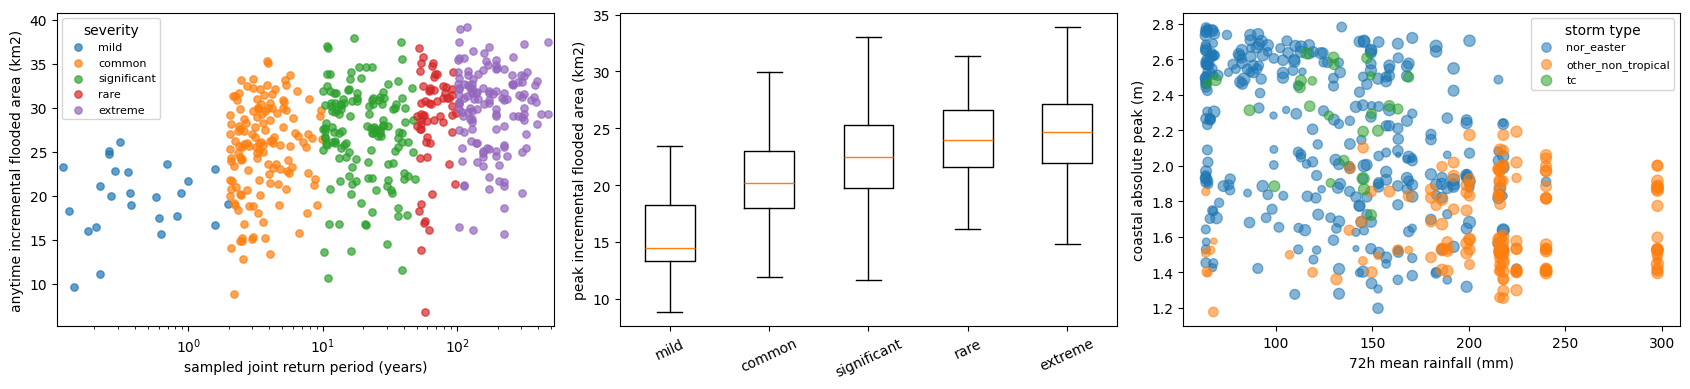

In [12]:
# Flood-engineering diagnostics: exported catalogue -> RP bands, storm classes, and response ranks.
flood_catalogue_path = outdir / "flood_event_outcome_catalogue.csv"
flood = pd.read_csv(flood_catalogue_path)

numeric_flood_cols = [
    "sample_rp_years", "coastal_absolute_peak_m", "rainfall_metric_mm", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "anytime_incremental_flooded_area_km2", "longest_incremental_flood_duration_h",
    "mean_incremental_flood_duration_h", "cumulative_incremental_flooded_area_km2h",
]
for col in numeric_flood_cols:
    flood[col] = pd.to_numeric(flood[col], errors="coerce")

# Return-period bins match common flood-risk communication thresholds: frequent, 10%, 2%, 1%, and 0.2% annual chances.
rp_breaks = [0, 2, 10, 50, 100, 500, np.inf]
rp_labels = ["<2 yr", "2-10 yr", "10-50 yr", "50-100 yr", "100-500 yr", ">500 yr"]
flood["rp_band"] = pd.cut(flood["sample_rp_years"], bins=rp_breaks, labels=rp_labels, right=False)
flood["has_incremental_flood"] = flood["anytime_incremental_flooded_area_km2"] > 0
p90 = lambda values: values.quantile(0.90)

# Band summary connects the sampled RP axis to depth, footprint, and duration consequences.
rp_band_stats = (
 flood.groupby(["rp_band", "severity_band"], observed=True).agg(
        event_count=("event_id", "nunique"),
        median_rp_years=("sample_rp_years", "median"),
        median_peak_boundary_m=("bzs_peak_max_m", "median"),
        median_rainfall_mm=("rainfall_metric_mm", "median"),
        flood_hit_rate=("has_incremental_flood", "mean"),
        median_peak_depth_m=("peak_incremental_land_depth_m", "median"),
        p90_peak_depth_m=("peak_incremental_land_depth_m", p90),
        median_peak_area_km2=("peak_incremental_flooded_area_km2", "median"),
        p90_anytime_area_km2=("anytime_incremental_flooded_area_km2", p90),
        p90_longest_duration_h=("longest_incremental_flood_duration_h", p90),
 ).reset_index
)

# Storm-type summary shows whether the flood response is controlled more by coastal-heavy or rainfall-heavy event families.
storm_type_stats = (
 flood.groupby(["storm_type", "severity_band"], observed=True).agg(
        event_count=("event_id", "nunique"),
        median_rp_years=("sample_rp_years", "median"),
        median_peak_boundary_m=("bzs_peak_max_m", "median"),
        median_rainfall_mm=("rainfall_metric_mm", "median"),
        median_peak_area_km2=("peak_incremental_flooded_area_km2", "median"),
        p90_anytime_area_km2=("anytime_incremental_flooded_area_km2", p90),
        p90_longest_duration_h=("longest_incremental_flood_duration_h", p90),
 ).reset_index
)

top_flood_events = flood.sort_values(
    ["anytime_incremental_flooded_area_km2", "peak_incremental_land_depth_m"],
    ascending=False,
)[[
    "event_id", "storm_type", "severity_band", "sample_rp_years",
    "coastal_absolute_peak_m", "rainfall_metric_mm", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "anytime_incremental_flooded_area_km2", "longest_incremental_flood_duration_h",
]].head(15)

display(pd.Series({
    "catalogue_csv": str(flood_catalogue_path),
    "events": int(len(flood)),
    "storm_types": ", ".join(sorted(flood["storm_type"].dropna().unique())),
    "max_anytime_incremental_area_km2": flood["anytime_incremental_flooded_area_km2"].max(),
    "max_peak_incremental_depth_m": flood["peak_incremental_land_depth_m"].max(),
}, name="flood_catalogue_scope"))
display(rp_band_stats.round(3))
display(storm_type_stats.round(3))
display(top_flood_events.round(3))

def _empty_panel(ax, message):
    ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])


def _positive_log_limits(values):
    positive = pd.to_numeric(values, errors="coerce")
    positive = positive[np.isfinite(positive) & (positive > 0)]
    if positive.empty:
        return None
    low = float(positive.min())
    high = float(positive.max())
    if np.isclose(low, high):
        return low / np.sqrt(10.0), high * np.sqrt(10.0)
    return low * 0.9, high * 1.1


severity_order = ["mild", "common", "significant", "rare", "extreme"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

rp_area_plotted = False
for severity_band, group in flood.groupby("severity_band", sort=False):
    x = pd.to_numeric(group["sample_rp_years"], errors="coerce")
    y = pd.to_numeric(group["anytime_incremental_flooded_area_km2"], errors="coerce")
    mask = np.isfinite(x) & (x > 0) & np.isfinite(y)
    if mask.any():
        axes[0].scatter(x[mask], y[mask], s=28, alpha=0.70, label=severity_band)
        rp_area_plotted = True
axes[0].set_xscale("log")
log_limits = _positive_log_limits(flood["sample_rp_years"])
if log_limits is not None:
    axes[0].set_xlim(*log_limits)
axes[0].set_xlabel("sampled joint return period (years)")
axes[0].set_ylabel("anytime incremental flooded area (km2)")
if rp_area_plotted:
    axes[0].legend(title="severity", fontsize=8)
else:
    _empty_panel(axes[0], "No finite area metrics available")

box_data = [
    pd.to_numeric(flood.loc[flood["severity_band"] == band, "peak_incremental_flooded_area_km2"], errors="coerce").dropna()
    for band in severity_order
]
if any(len(values) for values in box_data):
    axes[1].boxplot(box_data, tick_labels=severity_order, showfliers=False)
    axes[1].tick_params(axis="x", rotation=25)
else:
    _empty_panel(axes[1], "No finite peak-area metrics available")
axes[1].set_ylabel("peak incremental flooded area (km2)")

driver_plotted = False
for storm_type, group in flood.groupby("storm_type", sort=True):
    x = pd.to_numeric(group["rainfall_metric_mm"], errors="coerce")
    y = pd.to_numeric(group["coastal_absolute_peak_m"], errors="coerce")
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.any():
        area = pd.to_numeric(group.loc[mask, "anytime_incremental_flooded_area_km2"], errors="coerce").fillna(0.0)
        marker_size = np.clip(area * 2.0, 12, 90)
        axes[2].scatter(x[mask], y[mask], s=marker_size, alpha=0.55, label=storm_type)
        driver_plotted = True
axes[2].set_xlabel("72h mean rainfall (mm)")
axes[2].set_ylabel("coastal absolute peak (m)")
if driver_plotted:
    axes[2].legend(title="storm type", fontsize=8)
else:
    _empty_panel(axes[2], "No finite paired driver metrics available")

plt.tight_layout()
plt.show()


## Step 10: Catalog-weighted flood-depth probability maps

These maps belong with SFINCS evaluation because they integrate flood-truth outcomes over the Event Catalog probability weights. The maps are not renormalized if the completed run set is partial; the coverage receipt shows how much catalog probability mass is represented.


completed_outcome_events 500.0
catalog_weighted_events 500.0
covered_probability_weight 1.0
catalog_probability_weight 1.0
weight_coverage 1.0
Name: catalog_probability_coverage, dtype: float64

completed_event_count 500
covered_probability_weight 1.0
thresholds_ft [0.5, 1.0, 2.0]
probability_method 1 - exp(-sum(total_rate_per_year * probability...
Name: depth_probability_metadata, dtype: object

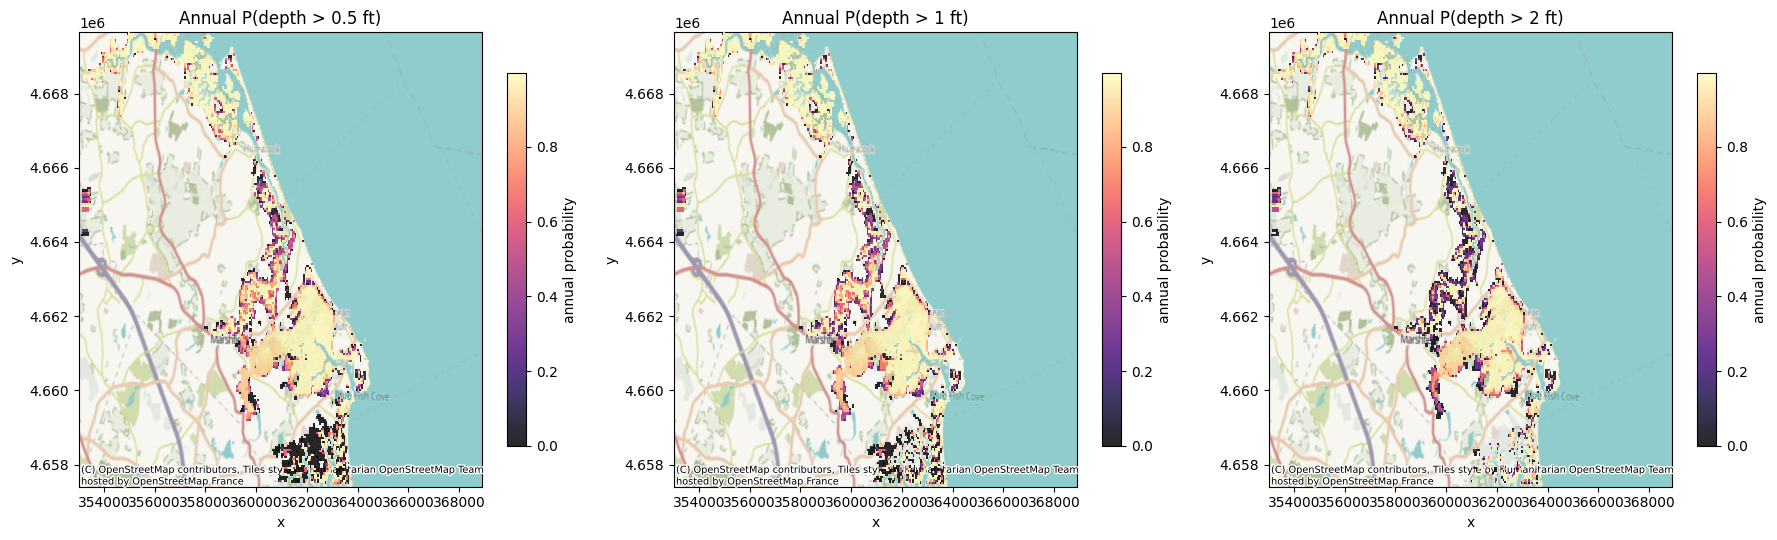

In [13]:
DEPTH_PROBABILITY_THRESHOLDS_FT = (0.5, 1.0, 2.0)

catalog_path = paths["design_outputs_root"] / "catalog" / "event_catalog.csv"
risk_metadata_path = paths["design_outputs_root"] / "catalog" / "catalog_risk_metadata.json"
metadata = json.loads(risk_metadata_path.read_text(encoding="utf-8"))
total_rate = float(metadata["total_rate_per_year"])

weights = pd.read_csv(catalog_path)
weights = weights[weights["event_origin"].isin(["synthetic_body", "synthetic_tail"])].copy()
weights["probability_weight"] = pd.to_numeric(weights["probability_weight"], errors="coerce")
weights = weights[weights["probability_weight"].notna()].reset_index(drop=True)

runs = sfincs_diagnostics.completed_sfincs_runs(paths["storage_root"])
flood_catalogue_path = outdir / "flood_event_outcome_catalogue.csv"
flood_catalogue = pd.read_csv(flood_catalogue_path)
probability_outcomes = sfincs_diagnostics.event_outcome_table(
    runs,
    catalog_path,
    weights,
    total_rate,
    outcomes=flood_catalogue,
)
probability_coverage = sfincs_diagnostics.outcome_coverage(probability_outcomes, weights)
display(probability_coverage)

depth_probability = sfincs_diagnostics.catalog_depth_probability(
    runs,
    probability_outcomes,
    thresholds_ft=DEPTH_PROBABILITY_THRESHOLDS_FT,
)
depth_probability_path = outdir / "flood_depth_probability.nc"
depth_probability.to_netcdf(depth_probability_path)
display(pd.Series(depth_probability.attrs, name="depth_probability_metadata"))

# Shared scale keeps the panels visually comparable.
vmax_values = []
for threshold in DEPTH_PROBABILITY_THRESHOLDS_FT:
    key = f"depth_gt_{str(float(threshold)).replace('.', 'p')}ft_aep"
    values = np.asarray(depth_probability[key].values, dtype=float)
    positive = values[np.isfinite(values) & (values > 0)]
    if positive.size:
        vmax_values.append(float(np.nanpercentile(positive, 99)))
shared_vmax = max(vmax_values) if vmax_values else 0.01

fig, axes = plt.subplots(1, len(DEPTH_PROBABILITY_THRESHOLDS_FT), figsize=(6 * len(DEPTH_PROBABILITY_THRESHOLDS_FT), 5.5), squeeze=False)
for ax, threshold in zip(axes[0], DEPTH_PROBABILITY_THRESHOLDS_FT):
    ax, mesh = sfincs_diagnostics.plot_depth_probability(
        depth_probability,
        threshold,
        ax=ax,
        basemap_style="osm",
        vmax=shared_vmax,
        title=f"Annual P(depth > {threshold:g} ft)",
    )
    cbar = fig.colorbar(mesh, ax=ax, shrink=0.82)
    cbar.set_label("annual probability")
plt.tight_layout()
plt.show()


## Step 11: Driver/flood-response diagnostic associations

This is a Maduwantha-style diagnostic review: storm-type colored driver/outcome panels and weighted standardized associations. It describes association between catalog drivers and SFINCS flood response; it is not counterfactual causal attribution.


,storm_type,outcome,driver,standardized_wls_coefficient,weighted_correlation,n_events,interpretation
54,other_non_tropical,longest_incremental_flood_duration_h,rainfall_scale_factor,1.011992,0.743198,151,"diagnostic association, not causal attribution"
30,tc,anytime_incremental_flooded_area_km2,rainfall_scale_factor,0.804953,0.379162,25,"diagnostic association, not causal attribution"
19,other_non_tropical,anytime_incremental_flooded_area_km2,rainfall,0.794290,0.542094,151,"diagnostic association, not causal attribution"
81,other_non_tropical,peak_incremental_flooded_area_km2,coastal_water_level,0.768250,0.283610,151,"diagnostic association, not causal attribution"
49,other_non_tropical,longest_incremental_flood_duration_h,coastal_water_level,-0.735360,0.151510,151,"diagnostic association, not causal attribution"
62,tc,longest_incremental_flood_duration_h,rainfall_scale_factor,-0.731642,-0.031571,25,"diagnostic association, not causal attribution"
83,other_non_tropical,peak_incremental_flooded_area_km2,rainfall,0.657373,0.532704,151,"diagnostic association, not causal attribution"
125,tc,peak_incremental_land_depth_m,rainfall_pairing_lag_hours,0.653913,0.566218,25,"diagnostic association, not causal attribution"
89,tc,peak_incremental_flooded_area_km2,coastal_water_level,0.633569,0.101991,25,"diagnostic association, not causal attribution"
82,other_non_tropical,peak_incremental_flooded_area_km2,coastal_water_level_scale_factor,-0.615917,0.266560,151,"diagnostic association, not causal attribution"


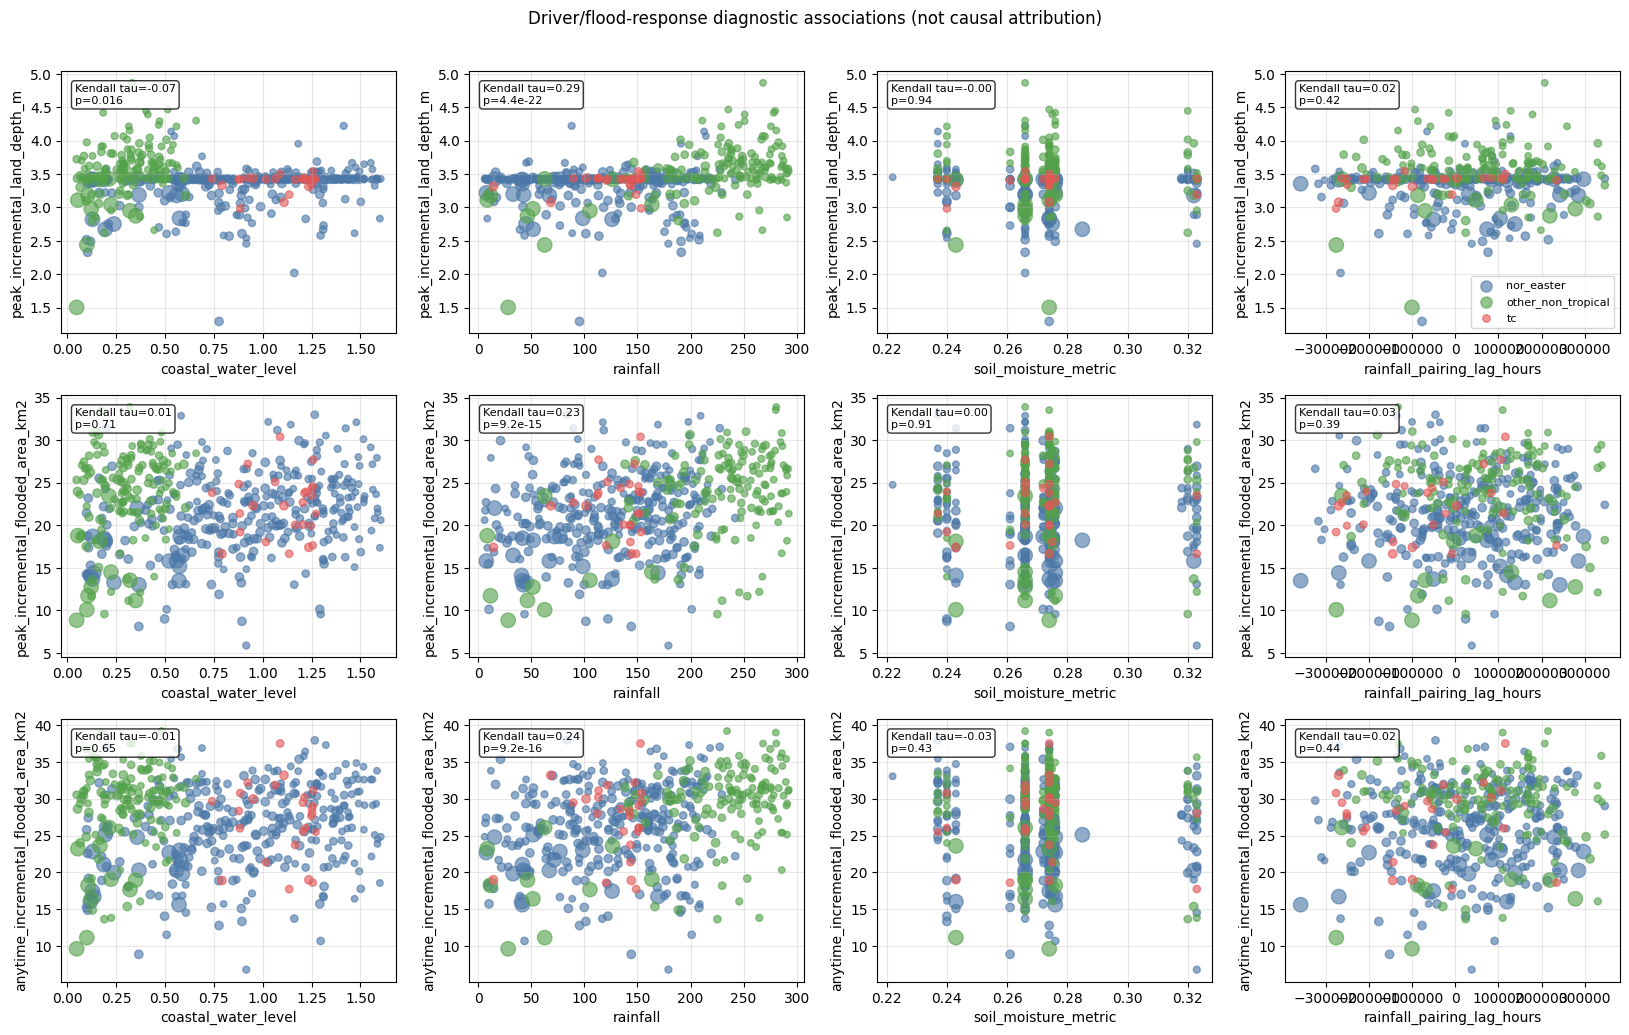

depth_probability_nc /home/grahamhults/projects/Flood-RM/locations/...
driver_flood_response_associations_csv /home/grahamhults/projects/Flood-RM/locations/...
Name: sfincs_probability_diagnostics_outputs, dtype: str

In [14]:
driver_columns = [
    "coastal_water_level",
    "coastal_absolute_peak_m",
    "rainfall",
    "rainfall_metric_mm",
    "soil_moisture_metric",
    "coastal_water_level_scale_factor",
    "rainfall_scale_factor",
    "rainfall_pairing_lag_hours",
]
outcome_columns = [
    "peak_incremental_land_depth_m",
    "peak_incremental_flooded_area_km2",
    "anytime_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h",
]
driver_columns = [c for c in driver_columns if c in probability_outcomes]
outcome_columns = [c for c in outcome_columns if c in probability_outcomes]

flood_driver_associations = sfincs_diagnostics.weighted_standardized_associations(
    probability_outcomes,
    drivers=driver_columns,
    outcomes=outcome_columns,
    min_rows=8,
)
associations_path = outdir / "driver_flood_response_diagnostic_associations.csv"
flood_driver_associations.to_csv(associations_path, index=False)
display(flood_driver_associations.sort_values(
    "standardized_wls_coefficient", key=lambda s: s.abs(), ascending=False
).head(30))

scatter_drivers = [c for c in ["coastal_water_level", "rainfall", "soil_moisture_metric", "rainfall_pairing_lag_hours"] if c in driver_columns]
scatter_outcomes = [c for c in ["peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2", "anytime_incremental_flooded_area_km2"] if c in outcome_columns]
if scatter_drivers and scatter_outcomes:
    sfincs_diagnostics.plot_driver_outcome_matrix(
    probability_outcomes,
        drivers=scatter_drivers,
        outcomes=scatter_outcomes,
    )
    plt.show()

pd.Series({
    "depth_probability_nc": str(depth_probability_path),
    "driver_flood_response_associations_csv": str(associations_path),
}, name="sfincs_probability_diagnostics_outputs")
